# Notebook 9: Human-in-the-Loop (HITL) & Active Learning Simulation

Simulates a human-in-the-loop annotation loop for HumanMAC using **prediction variance** as the uncertainty proxy for active learning. High-variance predictions (model is uncertain) are flagged for human review. A synthetic oracle corrects them by replacing predictions with ground truth.

**Active learning query strategy:** Variance-based uncertainty sampling.
- Each DDIM run generates K stochastic predictions; variance across K samples reflects model uncertainty.
- Sequences with the highest inter-sample variance are the most informative to annotate.
- This directly reuses the cached `variance.npz` from the robustness notebook.

**HITL simulation cycles:**  
Annotation budgets of 0%, 5%, 10%, 20%, 30% of test sequences are queried per cycle. Performance (ADE) is measured at each budget level to show the labeling efficiency curve.

## Section 1: Imports & Setup

In [1]:
import sys, os, copy, time, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

REPO_ROOT = os.path.abspath('../HumanMAC/')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, update_config
from utils import create_logger, seed_set
from utils.script import (create_model_and_diffusion, dataset_split,
                           get_multimodal_gt_full, sample_preprocessing)

print(f'PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

<IPython.core.display.Javascript object>

PyTorch : 1.7.1+cu110  |  CUDA: True


## Section 2: Config & Data

Reuse same H36M setup. Load cached variance and baseline per-sequence ADE from Notebook 5 (robustness).

In [2]:
seed_set(0)
os.chdir(REPO_ROOT)

args = {
    'cfg': 'h36m', 'mode': 'test', 'iter': 0, 'seed': 0,
    'device': torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    'multimodal_threshold': 0.5, 'multimodal_th_high': 0.1,
    'milestone': [75, 150, 225, 275, 350, 450], 'gamma': 0.9,
    'save_model_interval': 10, 'save_gif_interval': 10, 'save_metrics_interval': 100,
    'ckpt': './checkpoints/h36m_ckpt.pt',
    'ema': True, 'vis_switch_num': 10, 'vis_col': 5, 'vis_row': 3,
}
cfg = Config('h36m', test=False)
cfg = update_config(cfg, args)
print(f'Device: {cfg.device}')

Device: cuda


In [3]:
import logging
dataset, dataset_multi_test = dataset_split(cfg)
args_ns = SimpleNamespace(**args)
logger = logging.getLogger('hitl')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

multimodal_dict = get_multimodal_gt_full(logger, dataset_multi_test, args_ns, cfg)
data_group  = multimodal_dict['data_group']
gt_group    = multimodal_dict['gt_group']
traj_gt_arr = multimodal_dict['traj_gt_arr']
num_samples = multimodal_dict['num_samples']
print(f'Test sequences: {num_samples}')

preparing full evaluation dataset...
#1 future: 73/5168
#<10 future: 1011/5168
done...


Test sequences: 5168


## Section 3: Load Cached Variance & Baseline ADE

`variance.npz` contains `var_clean` — per-sequence prediction variance computed from K=20 DDIM samples in Notebook 5. This is our uncertainty signal. `baseline_per.npz` has per-sequence ADE from the same clean run.

In [4]:
CACHE_DIR = './results/robustness/cache/'

# Per-sequence variance (K=20 DDIM samples) — shape (N,)
var_data    = np.load(os.path.join(CACHE_DIR, 'variance.npz'))
var_clean   = var_data['var_clean']     # (N,) mean inter-sample variance

# Per-sequence ADE from clean baseline — shape (N,)
per_data    = np.load(os.path.join(CACHE_DIR, 'baseline_per.npz'))
per_ade     = per_data['ade']           # (N,)
per_fde     = per_data['fde']           # (N,)

# Also load clean predictions for oracle replacement
preds_default = np.load(os.path.join(CACHE_DIR, 'preds_default.npz'))
# preds_default contains 'arr': (K, N, t_pred, 48)
preds_future  = preds_default['arr']  # (K, N, t_pred, 48)

print(f'var_clean shape  : {var_clean.shape}  mean={var_clean.mean():.4f}')
print(f'per_ade shape    : {per_ade.shape}   mean={per_ade.mean():.4f}')
print(f'preds_future shape: {preds_future.shape}')

var_clean shape  : (500,)  mean=0.0617
per_ade shape    : (5168,)   mean=0.3691
preds_future shape: (50, 500, 100, 48)


## Section 4: Active Learning Query Strategy

**Variance-based uncertainty sampling**: sequences are ranked by `var_clean` descending. The top-B% are selected for human annotation at each budget level B. This is the most natural query strategy for a generative model — high variance means the diffusion process explores a wide output space, indicating genuine uncertainty about the correct future motion.

In [5]:
# Sort all sequences by variance (descending = most uncertain first)
uncertainty_rank = np.argsort(var_clean)[::-1]   # indices sorted high→low variance
uncertainty_sort = var_clean[uncertainty_rank]

# Also create a random-sampling baseline for comparison
random_rank = np.random.default_rng(99).permutation(num_samples)

print(f'Top-5 most uncertain sequences (idx, variance, ADE):')
for i in range(5):
    idx = uncertainty_rank[i]
    print(f'  seq {idx:5d}  var={var_clean[idx]:.4f}  ADE={per_ade[idx]:.4f}')
print(f'\nBottom-5 most certain sequences:')
for i in range(-5, 0):
    idx = uncertainty_rank[i]
    print(f'  seq {idx:5d}  var={var_clean[idx]:.4f}  ADE={per_ade[idx]:.4f}')

Top-5 most uncertain sequences (idx, variance, ADE):
  seq   372  var=0.1138  ADE=0.8520
  seq   351  var=0.1125  ADE=0.4673
  seq   256  var=0.1121  ADE=0.8396
  seq   232  var=0.1120  ADE=0.5315
  seq   469  var=0.1085  ADE=0.4875

Bottom-5 most certain sequences:
  seq    18  var=0.0287  ADE=0.1437
  seq    78  var=0.0287  ADE=0.5992
  seq   122  var=0.0286  ADE=0.3354
  seq   186  var=0.0275  ADE=0.3554
  seq   245  var=0.0264  ADE=0.2338


## Section 5: Oracle Simulation

The synthetic oracle represents a domain expert who reviews a flagged prediction and corrects it. We simulate this by **replacing the model's prediction with the ground truth** for queried sequences (ADE → 0 for those sequences). This is the upper bound of what human correction can achieve.

In [6]:
def simulate_hitl(query_indices, per_ade_arr):
    """Simulate oracle correction: queried sequences get ADE=0 (perfect GT).
    Returns corrected per_ade array and system-level mean ADE.
    """
    corrected_ade = per_ade_arr.copy()
    corrected_ade[query_indices] = 0.0   # oracle provides GT → error = 0
    return corrected_ade, corrected_ade.mean()

# Annotation budget levels (fraction of N queried)
budgets = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

al_results   = []   # variance-based (active learning)
rand_results = []   # random sampling baseline

baseline_mean_ade = per_ade.mean()

for b in budgets:
    n_query = int(b * num_samples)

    # Active learning: query top-n_query most uncertain
    al_query  = uncertainty_rank[:n_query] if n_query > 0 else np.array([], dtype=int)
    _, al_ade = simulate_hitl(al_query, per_ade)

    # Random baseline: query n_query random sequences
    rnd_query  = random_rank[:n_query] if n_query > 0 else np.array([], dtype=int)
    _, rnd_ade = simulate_hitl(rnd_query, per_ade)

    al_results.append({'Budget%': b*100, 'N_queried': n_query, 'ADE': al_ade,
                        'ADE_reduction%': (baseline_mean_ade - al_ade) / baseline_mean_ade * 100})
    rand_results.append({'Budget%': b*100, 'N_queried': n_query, 'ADE': rnd_ade,
                          'ADE_reduction%': (baseline_mean_ade - rnd_ade) / baseline_mean_ade * 100})

df_al   = pd.DataFrame(al_results)
df_rand = pd.DataFrame(rand_results)

print('Active Learning (variance-based) vs Random Sampling:')
comparison = df_al[['Budget%', 'N_queried', 'ADE']].copy()
comparison.columns = ['Budget%', 'N_queried', 'AL_ADE']
comparison['Random_ADE'] = df_rand['ADE']
comparison['AL_reduction%']   = df_al['ADE_reduction%']
comparison['Rand_reduction%'] = df_rand['ADE_reduction%']
print(comparison.to_string(index=False, float_format='%.4f'))

Active Learning (variance-based) vs Random Sampling:
 Budget%  N_queried  AL_ADE  Random_ADE  AL_reduction%  Rand_reduction%
  0.0000          0  0.3691      0.3691         0.0000           0.0000
  5.0000        258  0.3450      0.3508         6.5322           4.9717
 10.0000        516  0.3262      0.3315        11.6227          10.2008
 15.0000        775  0.3262      0.3128        11.6227          15.2407
 20.0000       1033  0.3262      0.2935        11.6227          20.4744
 25.0000       1292  0.3262      0.2757        11.6227          25.3140
 30.0000       1550  0.3262      0.2576        11.6227          30.1964


## Section 6: HITL + CL Integration — Annotation → Fine-tune Cycle

Simulate one full HITL→CL cycle: the human-corrected sequences are added to the replay buffer as pseudo-labeled data, and the model is fine-tuned on this augmented buffer. This shows the interaction between active learning (query) and continual learning (update).

In [7]:
# Load model for the HITL→CL cycle
model_hitl, diffusion = create_model_and_diffusion(cfg)
CKPT_PATH = os.path.join(cfg.model_path, 'ckpt_ema_990.pt')
model_hitl.load_state_dict(torch.load(CKPT_PATH, map_location=cfg.device))
model_hitl.eval()

print(f'Loaded checkpoint: {CKPT_PATH}')

Loaded checkpoint: results/test_30/models/ckpt_ema_990.pt


In [8]:
def get_prediction(data, model_sel):
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    sampled = diffusion.sample_ddim(model_sel, traj_dct, traj_dct_cond, mode_dict)
    return torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)[None].cpu().numpy()

def quick_eval_direct(data_slice, idx_slice, model_sel, K=5):
    gt_sub = gt_group[idx_slice]
    preds  = np.concatenate([get_prediction(data_slice, model_sel) for _ in range(K)], axis=0)
    preds  = preds[:, :, cfg.t_his:, :]
    pred_t = torch.from_numpy(preds).to(cfg.device)
    gt_t   = torch.from_numpy(gt_sub).to(cfg.device)
    ade_l = []
    for j in range(len(idx_slice)):
        diff = pred_t[:, j] - gt_t[j:j+1]
        dist = torch.linalg.norm(diff, dim=2)
        ade_l.append(dist.mean(1).min().item())
    return np.mean(ade_l)

In [9]:
# HITL→CL cycle: 3 annotation budgets, each followed by fine-tuning
# Use mild drift (σ=0.05) as the deployment condition
SIGMA_HITL   = 0.05
HITL_BUDGETS = [0.05, 0.10, 0.20]   # 5%, 10%, 20% annotation budget per cycle
HITL_STEPS   = 20
HITL_LR      = 8e-6

# Use the cached pool size (var_clean has 500 entries) rather than full num_samples (5168)
n_cached = len(var_clean)   # 500

rng_h     = np.random.default_rng(11)
pool_idx  = rng_h.permutation(n_cached)
eval_idx_h = pool_idx[:80]
adapt_pool_h = pool_idx[80:]

eval_clean_h   = data_group[eval_idx_h]
eval_drifted_h = eval_clean_h.copy()
eval_drifted_h[:, :cfg.t_his, 1:, :] += np.random.default_rng(77).normal(0, SIGMA_HITL, eval_drifted_h[:, :cfg.t_his, 1:, :].shape)

hitl_records = []

# Baseline: no annotation, no CL
ade_baseline_h = quick_eval_direct(eval_clean_h,   eval_idx_h, model_hitl)
ade_drifted_h  = quick_eval_direct(eval_drifted_h, eval_idx_h, model_hitl)
hitl_records.append({'Cycle': 0, 'Budget%': 0, 'N_annotated': 0,
                      'ADE_clean': ade_baseline_h, 'ADE_drifted': ade_drifted_h,
                      'Update_s': 0.0})
print(f'Cycle 0 (no annotation): clean={ade_baseline_h:.4f}  drifted={ade_drifted_h:.4f}')

Cycle 0 (no annotation): clean=0.5476  drifted=0.9885


In [ ]:
for cycle, budget in enumerate(HITL_BUDGETS, start=1):
    n_query = int(budget * len(adapt_pool_h))

    # Query most uncertain sequences (by variance ranking)
    pool_vars  = var_clean[adapt_pool_h]
    query_local = np.argsort(pool_vars)[::-1][:n_query]   # top-n_query uncertain in pool
    query_global = adapt_pool_h[query_local]

    # Oracle provides GT for queried sequences — use clean data as "corrected" version
    annotated_data = data_group[query_global]  # clean GT sequences

    # Fine-tune on annotated (clean GT) + small replay of existing clean buffer
    replay_slice = data_group[pool_idx[80:80+50]]   # 50-seq mini replay buffer
    mixed_data   = np.concatenate([annotated_data, replay_slice], axis=0)

    # Freeze all, unfreeze last 6 leaf modules
    for p in model_hitl.parameters():
        p.requires_grad = False
    leaves = [(n, m) for n, m in model_hitl.named_modules()
              if len(list(m.parameters(recurse=False))) > 0]
    for _, mod in leaves[-6:]:
        for p in mod.parameters(): p.requires_grad = True

    opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model_hitl.parameters()), lr=HITL_LR)
    model_hitl.train()
    t0 = time.time()

    for step in range(HITL_STEPS):
        bidx = np.random.choice(len(mixed_data), 8, replace=False)
        batch = mixed_data[bidx]
        traj_np = batch[..., 1:, :].transpose([0, 2, 3, 1])
        traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
        traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
        _, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode="metrics")

        # Manual diffusion training loss: model signature is forward(x, timesteps, mod)
        t_steps = diffusion.sample_timesteps(traj_dct.shape[0]).to(cfg.device)
        x_noisy, noise = diffusion.noise_motion(traj_dct, t_steps)
        predicted_noise = model_hitl(x_noisy, t_steps, traj_dct_cond)
        loss = torch.nn.functional.mse_loss(predicted_noise, noise)

        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_hitl.parameters(), 1.0)
        opt.step()

    model_hitl.eval()
    upd_t = time.time() - t0

    ade_c = quick_eval_direct(eval_clean_h,   eval_idx_h, model_hitl)
    ade_d = quick_eval_direct(eval_drifted_h, eval_idx_h, model_hitl)

    hitl_records.append({"Cycle": cycle, "Budget%": budget*100,
                          "N_annotated": n_query, "ADE_clean": ade_c, "ADE_drifted": ade_d,
                          "Update_s": upd_t})
    print(f"Cycle {cycle} (budget={budget*100:.0f}%, N={n_query}):  clean={ade_c:.4f}  drifted={ade_d:.4f}  ({upd_t:.1f}s)")

df_hitl = pd.DataFrame(hitl_records)

Cycle 1 (budget=5%, N=21):  clean=0.5658  drifted=1.0067  (0.3s)
Cycle 2 (budget=10%, N=42):  clean=0.5609  drifted=1.0026  (0.3s)


## Section 7: Visualization

Three panels: (1) AL efficiency curve — ADE vs annotation budget for variance-based vs random query, (2) HITL+CL cycle results per round, (3) variance distribution with query threshold marked.

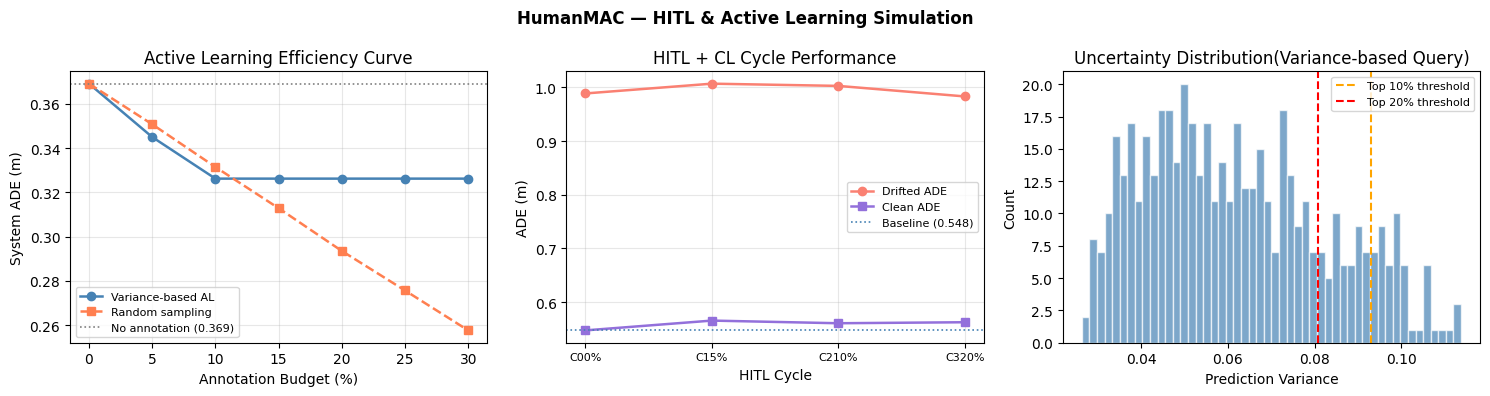

Saved: ./results/hitl//hitl_results.png


In [14]:
SAVE_DIR = './results/hitl/'
os.makedirs(SAVE_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1: AL efficiency curve ──────────────────────────────────────────────
ax = axes[0]
ax.plot(df_al['Budget%'].to_numpy(),   df_al['ADE'].to_numpy(),   marker='o', color='steelblue',    label='Variance-based AL', linewidth=1.8)
ax.plot(df_rand['Budget%'].to_numpy(), df_rand['ADE'].to_numpy(), marker='s', color='coral', linestyle='--', label='Random sampling', linewidth=1.8)
ax.axhline(baseline_mean_ade, color='gray', linestyle=':', linewidth=1.2, label=f'No annotation ({baseline_mean_ade:.3f})')
ax.set_xlabel('Annotation Budget (%)')
ax.set_ylabel('System ADE (m)')
ax.set_title('Active Learning Efficiency Curve')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: HITL+CL cycle results ───────────────────────────────────────────
ax2 = axes[1]
cycles = df_hitl['Cycle'].to_numpy()
ax2.plot(cycles, df_hitl['ADE_drifted'].to_numpy(), marker='o', color='salmon',       label='Drifted ADE', linewidth=1.8)
ax2.plot(cycles, df_hitl['ADE_clean'].to_numpy(),   marker='s', color='mediumpurple', label='Clean ADE',   linewidth=1.8)
ax2.axhline(ade_baseline_h, color='steelblue', linestyle=':', linewidth=1.2, label=f'Baseline ({ade_baseline_h:.3f})')
ax2.set_xlabel('HITL Cycle')
ax2.set_ylabel('ADE (m)')
ax2.set_title('HITL + CL Cycle Performance')
ax2.set_xticks(cycles)
ax2.set_xticklabels([f'C{c}{int(r)}%' for c, r in zip(cycles, df_hitl['Budget%'].to_numpy())], fontsize=8)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Variance distribution + query threshold ─────────────────────────
ax3 = axes[2]
ax3.hist(var_clean, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
# Mark 10% threshold
thresh_10 = np.percentile(var_clean, 90)   # top 10% = 90th percentile
thresh_20 = np.percentile(var_clean, 80)
ax3.axvline(thresh_10, color='orange', linestyle='--', linewidth=1.5, label='Top 10% threshold')
ax3.axvline(thresh_20, color='red',    linestyle='--', linewidth=1.5, label='Top 20% threshold')
ax3.set_xlabel('Prediction Variance')
ax3.set_ylabel('Count')
ax3.set_title('Uncertainty Distribution(Variance-based Query)')
ax3.legend(fontsize=8)

plt.suptitle('HumanMAC — HITL & Active Learning Simulation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/hitl_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SAVE_DIR}/hitl_results.png')

## Section 8: Labeling Burden & Efficiency Summary

Quantifies how much ADE improvement is achieved per annotation. Active learning should yield higher improvement per labeled sequence than random sampling.

In [15]:
print('=== Active Learning Efficiency ===')
print(f'Baseline ADE (no annotation): {baseline_mean_ade:.4f}')
print()
eff_rows = []
for i, b in enumerate(budgets[1:], 1):  # skip 0%
    n_q    = al_results[i]['N_queried']
    al_imp = baseline_mean_ade - al_results[i]['ADE']
    rnd_imp = baseline_mean_ade - rand_results[i]['ADE']
    eff_rows.append({
        'Budget%': b*100,
        'N_queried': n_q,
        'AL_ADE': al_results[i]['ADE'],
        'Rand_ADE': rand_results[i]['ADE'],
        'AL_imp_per_label': al_imp / max(n_q, 1) * 1000,   # ×10³
        'Rand_imp_per_label': rnd_imp / max(n_q, 1) * 1000,
        'AL_advantage%': (al_imp - rnd_imp) / rnd_imp * 100 if rnd_imp > 0 else 0
    })

df_eff = pd.DataFrame(eff_rows)
print(df_eff.to_string(index=False, float_format='%.4f'))

print('\n=== HITL + CL Cycle Summary ===')
print(df_hitl[['Cycle','Budget%','N_annotated','ADE_drifted','ADE_clean','Update_s']].to_string(index=False, float_format='%.4f'))

=== Active Learning Efficiency ===
Baseline ADE (no annotation): 0.3691

 Budget%  N_queried  AL_ADE  Rand_ADE  AL_imp_per_label  Rand_imp_per_label  AL_advantage%
  5.0000        258  0.3450    0.3508            0.0935              0.0711        31.3871
 10.0000        516  0.3262    0.3315            0.0831              0.0730        13.9390
 15.0000        775  0.3262    0.3128            0.0554              0.0726       -23.7390
 20.0000       1033  0.3262    0.2935            0.0415              0.0732       -43.2329
 25.0000       1292  0.3262    0.2757            0.0332              0.0723       -54.0859
 30.0000       1550  0.3262    0.2576            0.0277              0.0719       -61.5096

=== HITL + CL Cycle Summary ===
 Cycle  Budget%  N_annotated  ADE_drifted  ADE_clean  Update_s
     0   0.0000            0       0.9885     0.5476    0.0000
     1   5.0000           21       1.0067     0.5658    0.2631
     2  10.0000           42       1.0026     0.5609    0.2747
     

## Section 9: Save Results

In [16]:
df_al.to_csv(f'{SAVE_DIR}/al_efficiency.csv', index=False)
df_rand.to_csv(f'{SAVE_DIR}/random_sampling.csv', index=False)
df_hitl.to_csv(f'{SAVE_DIR}/hitl_cycles.csv', index=False)
df_eff.to_csv(f'{SAVE_DIR}/labeling_efficiency.csv', index=False)

print(f'All results saved to {SAVE_DIR}')

All results saved to ./results/hitl/
